# Auditoria 2: revision visual de etiquetas

Este notebook sirve para inspeccionar la señal de cada segmento de 3 segundos y decidir si la etiqueta automatica apunta al primer y segundo tap correctos. Lee archivos existentes y no escribe sidecars, CSV ni checkpoints.

La revision se hace en dos niveles:

1. Una vista completa de 20 segmentos para identificar patrones anormales o segmentos que merecen zoom.
2. Una figura detallada de un segmento, con acelerometro, giroscopio, la energia que usa el autoetiquetador y las etiquetas densas.


## Como emitir un veredicto humano

Para cada segmento positivo registra un solo veredicto en la celda de `review_decisions` al final:

- `correct`: hay dos impactos distinguibles; el marcador naranja es un primer tap plausible y el marcador verde coincide con el segundo tap.
- `uncertain`: hay ruido, vibracion o varios candidatos y no puedes defender con confianza que la pareja seleccionada es la correcta.
- `incorrect`: falta un tap, la etiqueta verde cae en vibracion posterior/anterior, o corresponde a otro movimiento.

El color naranja es `n1` recalculado por el heuristico. El verde es `n2` guardado en el sidecar y usado por entrenamiento. El rojo es `n2` recalculado. Si verde y rojo coinciden, solo significa que la etiqueta fue producida por el algoritmo actual; no es confirmacion humana.


In [1]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'tap_recognition').is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'tap_recognition').is_dir(), 'Run this notebook from the repository root or notebooks/.'
sys.path.insert(0, str(REPO_ROOT))

from tap_recognition.dataset import load_full_recording, load_segment_row_bounds, load_trigger_events
from tap_recognition.labels import (
    CLASS_LEFT,
    CLASS_RIGHT,
    acc_energy_delta,
    detect_second_tap_frame,
    three_class_frame_labels,
)
from tap_recognition.physics import IMUSimulator

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})
POSITIVE_ACTION_TO_CLASS = {'knock_twice_left': CLASS_LEFT, 'knock_twice_right': CLASS_RIGHT}
CLASS_NAME = {0: 'none', CLASS_LEFT: 'left', CLASS_RIGHT: 'right'}
IMU_NAMES = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
IMU_COLORS = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#d62728', '#8c564b']
CSV_PATHS = sorted((REPO_ROOT / 'data').glob('*/*.csv'))
print('Recordings available:', len(CSV_PATHS))
print('This notebook needs pandas for review tables. It is not currently listed in requirements.txt.')


Recordings available: 116
This notebook needs pandas for review tables. It is not currently listed in requirements.txt.


## Cargar una grabacion sin alterar sus etiquetas

Los marcadores y señales se calculan sobre la señal cruda porque `tools/auto_label_imu.py` llama a `detect_second_tap_frame` sobre el CSV sin high-pass. La fila de alta frecuencia se dibuja como ayuda visual, pero no es la señal que decidio la etiqueta. Esta diferencia es importante para detectar discrepancias entre etiquetado y entrenamiento.


In [2]:
def read_metadata_and_timestamps(csv_path: Path) -> tuple[dict[str, str], np.ndarray]:
    with csv_path.open(encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f'No rows in {csv_path}')
    return rows[0], np.asarray([float(row['timestamp_ms']) for row in rows])


def resolve_csv_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    candidate = REPO_ROOT / path
    return candidate if candidate.exists() else path


def load_recording_for_review(path: str | Path) -> dict[str, object]:
    csv_path = resolve_csv_path(path)
    metadata, timestamps_ms = read_metadata_and_timestamps(csv_path)
    imu, sample_rate = load_full_recording(csv_path)
    bounds = load_segment_row_bounds(csv_path)
    events = load_trigger_events(csv_path.with_suffix('.txt'))
    dense_path = csv_path.with_name(csv_path.stem + '.labels.txt')
    dense = None
    if dense_path.exists() and dense_path.stat().st_size:
        dense = np.loadtxt(dense_path, delimiter=',', skiprows=1, ndmin=2)
    return {
        'path': csv_path,
        'metadata': metadata,
        'timestamps_ms': timestamps_ms,
        'imu': imu,
        'sample_rate': sample_rate,
        'bounds': bounds,
        'events': events,
        'dense': dense,
    }


def segment_payload(recording: dict[str, object], segment_index: int) -> dict[str, object]:
    bounds = recording['bounds']
    if segment_index < 1 or segment_index > len(bounds):
        raise ValueError(f'segment_index must be in [1, {len(bounds)}]')
    start, end = bounds[segment_index - 1]
    imu = recording['imu']
    fs = recording['sample_rate']
    local_events = [(frame, class_id) for frame, class_id in recording['events'] if start <= frame < end]
    pair = detect_second_tap_frame(imu[start:end, :3], imu[start:end, 3:], sample_rate=fs)
    auto_n1 = start + pair[0] if pair is not None else None
    auto_n2 = start + pair[1] if pair is not None else None
    local_dense = None
    if recording['dense'] is not None:
        local_dense = recording['dense'][start:end]
    else:
        local_dense = three_class_frame_labels(
            end - start,
            [(frame - start, class_id) for frame, class_id in local_events],
            half_frames=10,
        )
    return {
        'segment_index': segment_index,
        'start': start,
        'end': end,
        'imu': imu[start:end],
        'timestamps_ms': recording['timestamps_ms'][start:end],
        'events': local_events,
        'auto_n1': auto_n1,
        'auto_n2': auto_n2,
        'dense': local_dense,
        'sample_rate': fs,
    }


def marker_time(frame: int | None, payload: dict[str, object]) -> float | None:
    if frame is None:
        return None
    return (frame - payload['start']) / payload['sample_rate']


def add_markers(ax: plt.Axes, payload: dict[str, object], show_legend: bool = True) -> None:
    n1_t = marker_time(payload['auto_n1'], payload)
    n2_t = marker_time(payload['auto_n2'], payload)
    if n1_t is not None:
        ax.axvline(n1_t, color='#e69138', linestyle=':', linewidth=1.8, label='auto n1' if show_legend else None)
    if n2_t is not None:
        ax.axvline(n2_t, color='#cc3333', linestyle='--', linewidth=1.2, label='auto n2' if show_legend else None)
    for event_number, (frame, class_id) in enumerate(payload['events']):
        label = 'stored n2' if show_legend and event_number == 0 else None
        ax.axvline(marker_time(frame, payload), color='#2ca02c', linestyle='-', linewidth=2.0, label=label)


## Vista detallada de un segmento

Cambia `CSV_PATH` y `SEGMENT_INDEX` para revisar cualquier caso. La tercera fila, `raw acceleration-energy delta`, es la principal para auditar el autoetiquetador porque es la senal que usa para elegir la pareja. Los picos de alta frecuencia pueden ser mas faciles de interpretar, pero no son su entrada.


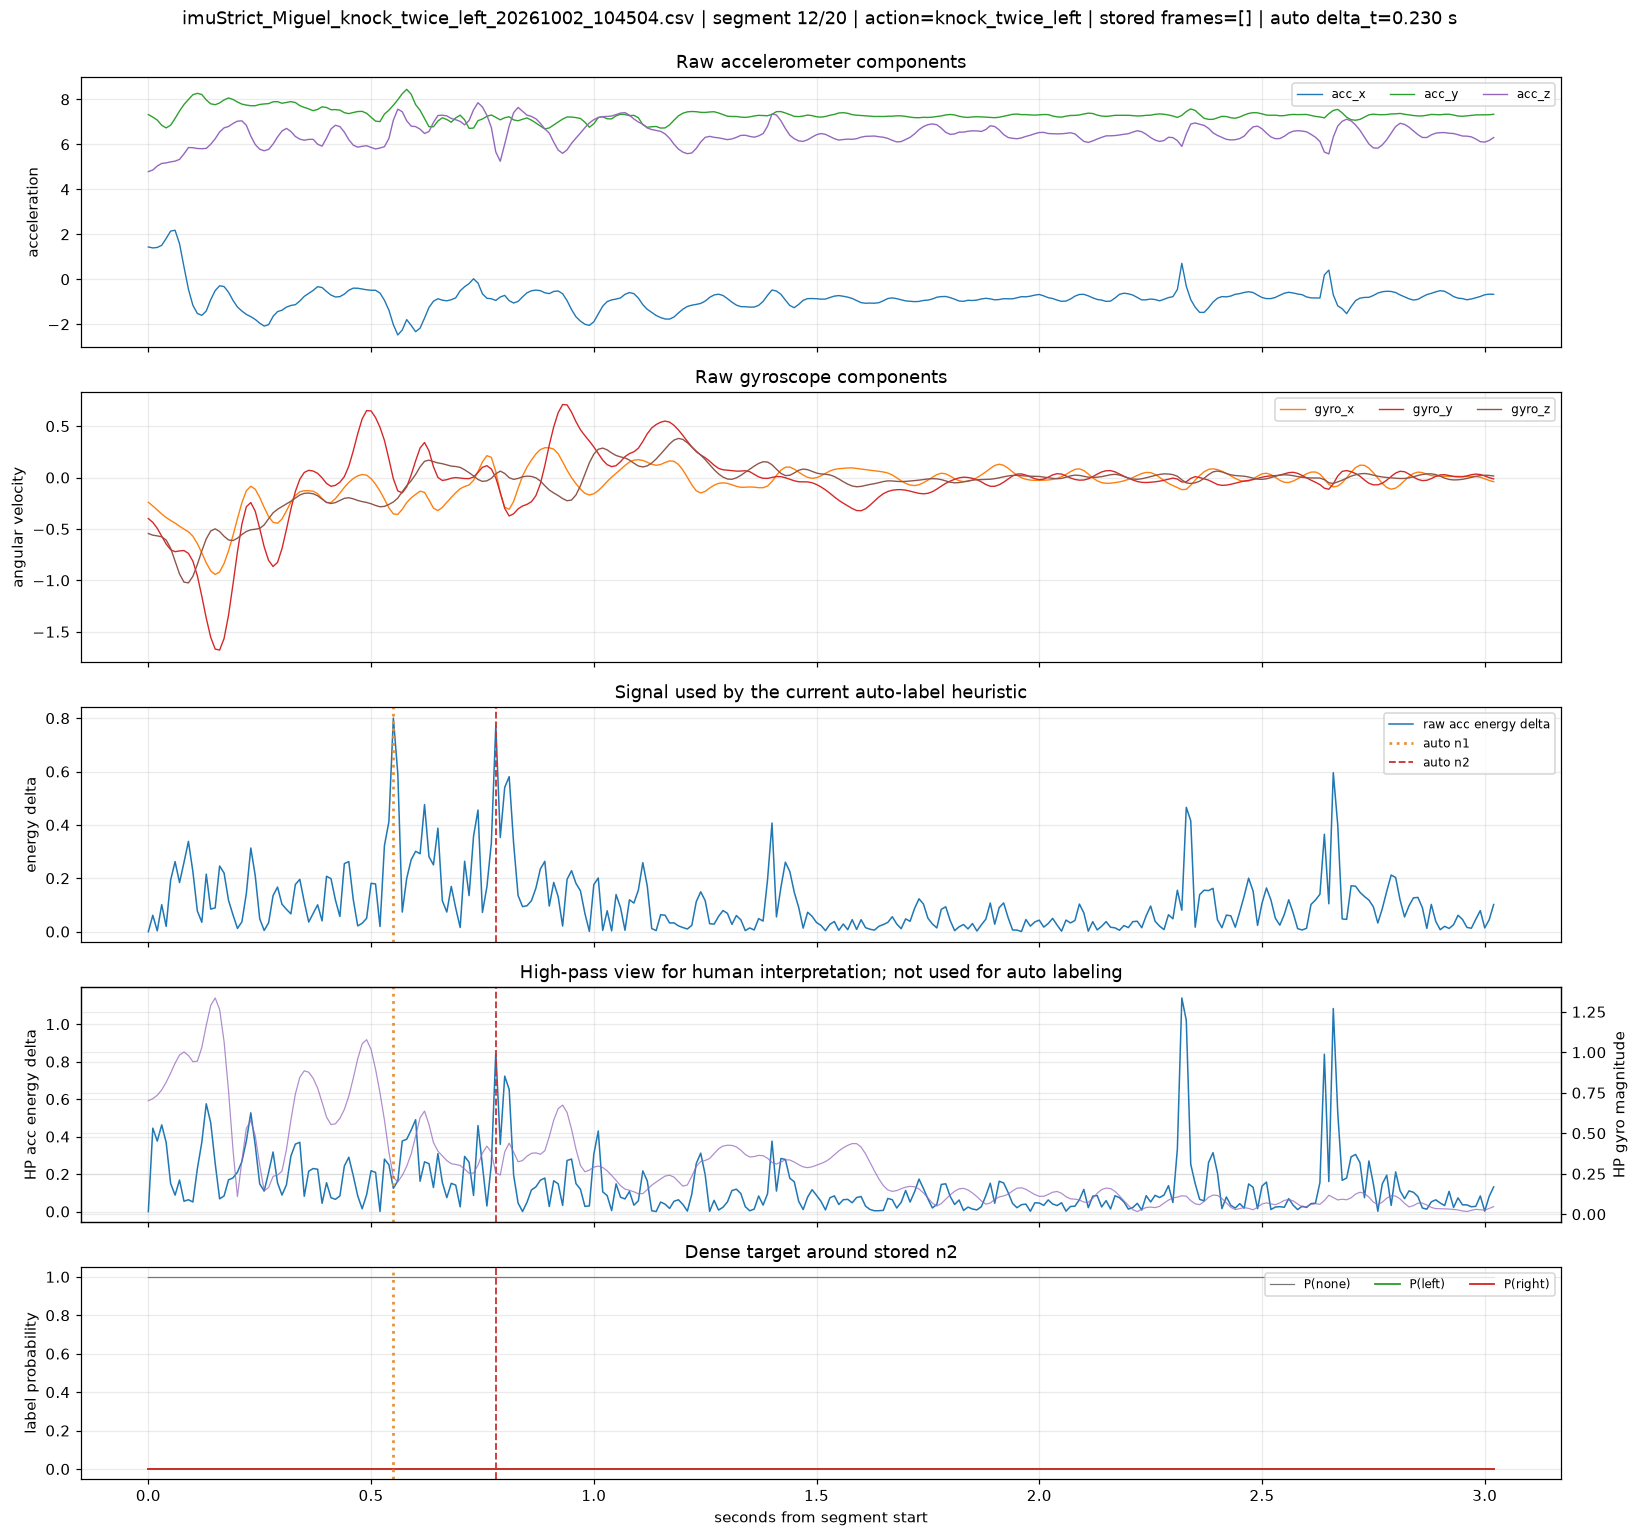

In [15]:
CSV_PATH = Path('''data_02_10_26/train_data/imuStrict_Miguel_knock_twice_left_20261002_104504.csv''')
SEGMENT_INDEX = 12


def plot_segment_review(path: str | Path, segment_index: int) -> None:
    recording = load_recording_for_review(path)
    payload = segment_payload(recording, segment_index)
    imu = payload['imu']
    fs = payload['sample_rate']
    t = np.arange(len(imu)) / fs
    raw_acc_energy = acc_energy_delta(imu[:, :3])
    raw_gyro_magnitude = np.linalg.norm(imu[:, 3:], axis=1)
    hp = IMUSimulator(sample_rate=fs, window_samples=len(imu)).highpass(imu)
    hp_acc_energy = acc_energy_delta(hp[:, :3])
    hp_gyro_magnitude = np.linalg.norm(hp[:, 3:], axis=1)

    fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True, gridspec_kw={'height_ratios': [1.15, 1.15, 1.0, 1.0, 0.9]})
    for channel in range(3):
        axes[0].plot(t, imu[:, channel], color=IMU_COLORS[channel], linewidth=0.9, label=IMU_NAMES[channel])
    axes[0].set_ylabel('acceleration')
    axes[0].set_title('Raw accelerometer components')
    axes[0].legend(loc='upper right', ncol=3, fontsize=8)

    for channel in range(3, 6):
        axes[1].plot(t, imu[:, channel], color=IMU_COLORS[channel], linewidth=0.9, label=IMU_NAMES[channel])
    axes[1].set_ylabel('angular velocity')
    axes[1].set_title('Raw gyroscope components')
    axes[1].legend(loc='upper right', ncol=3, fontsize=8)

    axes[2].plot(t, raw_acc_energy, color='#1f77b4', linewidth=1.0, label='raw acc energy delta')
    add_markers(axes[2], payload)
    axes[2].set_ylabel('energy delta')
    axes[2].set_title('Signal used by the current auto-label heuristic')
    axes[2].legend(loc='upper right', fontsize=8)

    axes[3].plot(t, hp_acc_energy, color='#1f77b4', linewidth=1.0, label='high-pass acc energy delta')
    gyro_axis = axes[3].twinx()
    gyro_axis.plot(t, hp_gyro_magnitude, color='#9467bd', linewidth=0.8, alpha=0.75, label='high-pass gyro magnitude')
    add_markers(axes[3], payload, show_legend=False)
    axes[3].set_ylabel('HP acc energy delta')
    gyro_axis.set_ylabel('HP gyro magnitude')
    axes[3].set_title('High-pass view for human interpretation; not used for auto labeling')

    labels = payload['dense']
    axes[4].plot(t, labels[:, 0], color='#777777', linewidth=0.8, label='P(none)')
    axes[4].plot(t, labels[:, 1], color='#2ca02c', linewidth=1.2, label='P(left)')
    axes[4].plot(t, labels[:, 2], color='#d62728', linewidth=1.2, label='P(right)')
    add_markers(axes[4], payload, show_legend=False)
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel('label probability')
    axes[4].set_xlabel('seconds from segment start')
    axes[4].set_title('Dense target around stored n2')
    axes[4].legend(loc='upper right', ncol=3, fontsize=8)

    if payload['auto_n1'] is None:
        auto_text = 'no automatic pair'
    else:
        delta_t = (payload['auto_n2'] - payload['auto_n1']) / fs
        auto_text = f'auto delta_t={delta_t:.3f} s'
    stored_frames = [frame for frame, _ in payload['events']]
    title = (
        f"{recording['path'].name} | segment {segment_index}/{len(recording['bounds'])} | "
        f"action={recording['metadata'].get('action_label', '')} | stored frames={stored_frames} | {auto_text}"
    )
    fig.suptitle(title, y=0.995, fontsize=12)
    fig.tight_layout()
    plt.show()


plot_segment_review(CSV_PATH, SEGMENT_INDEX)


## Vista de una grabacion completa

Cada panel del contact sheet es un segmento. La curva azul es exactamente la energia de aceleracion usada por el heuristico; naranja, rojo y verde tienen el mismo significado que antes. Esta vista permite comprobar visualmente que cada grabacion tiene una accion repetida 20 veces y localizar rapidamente pares extraños.


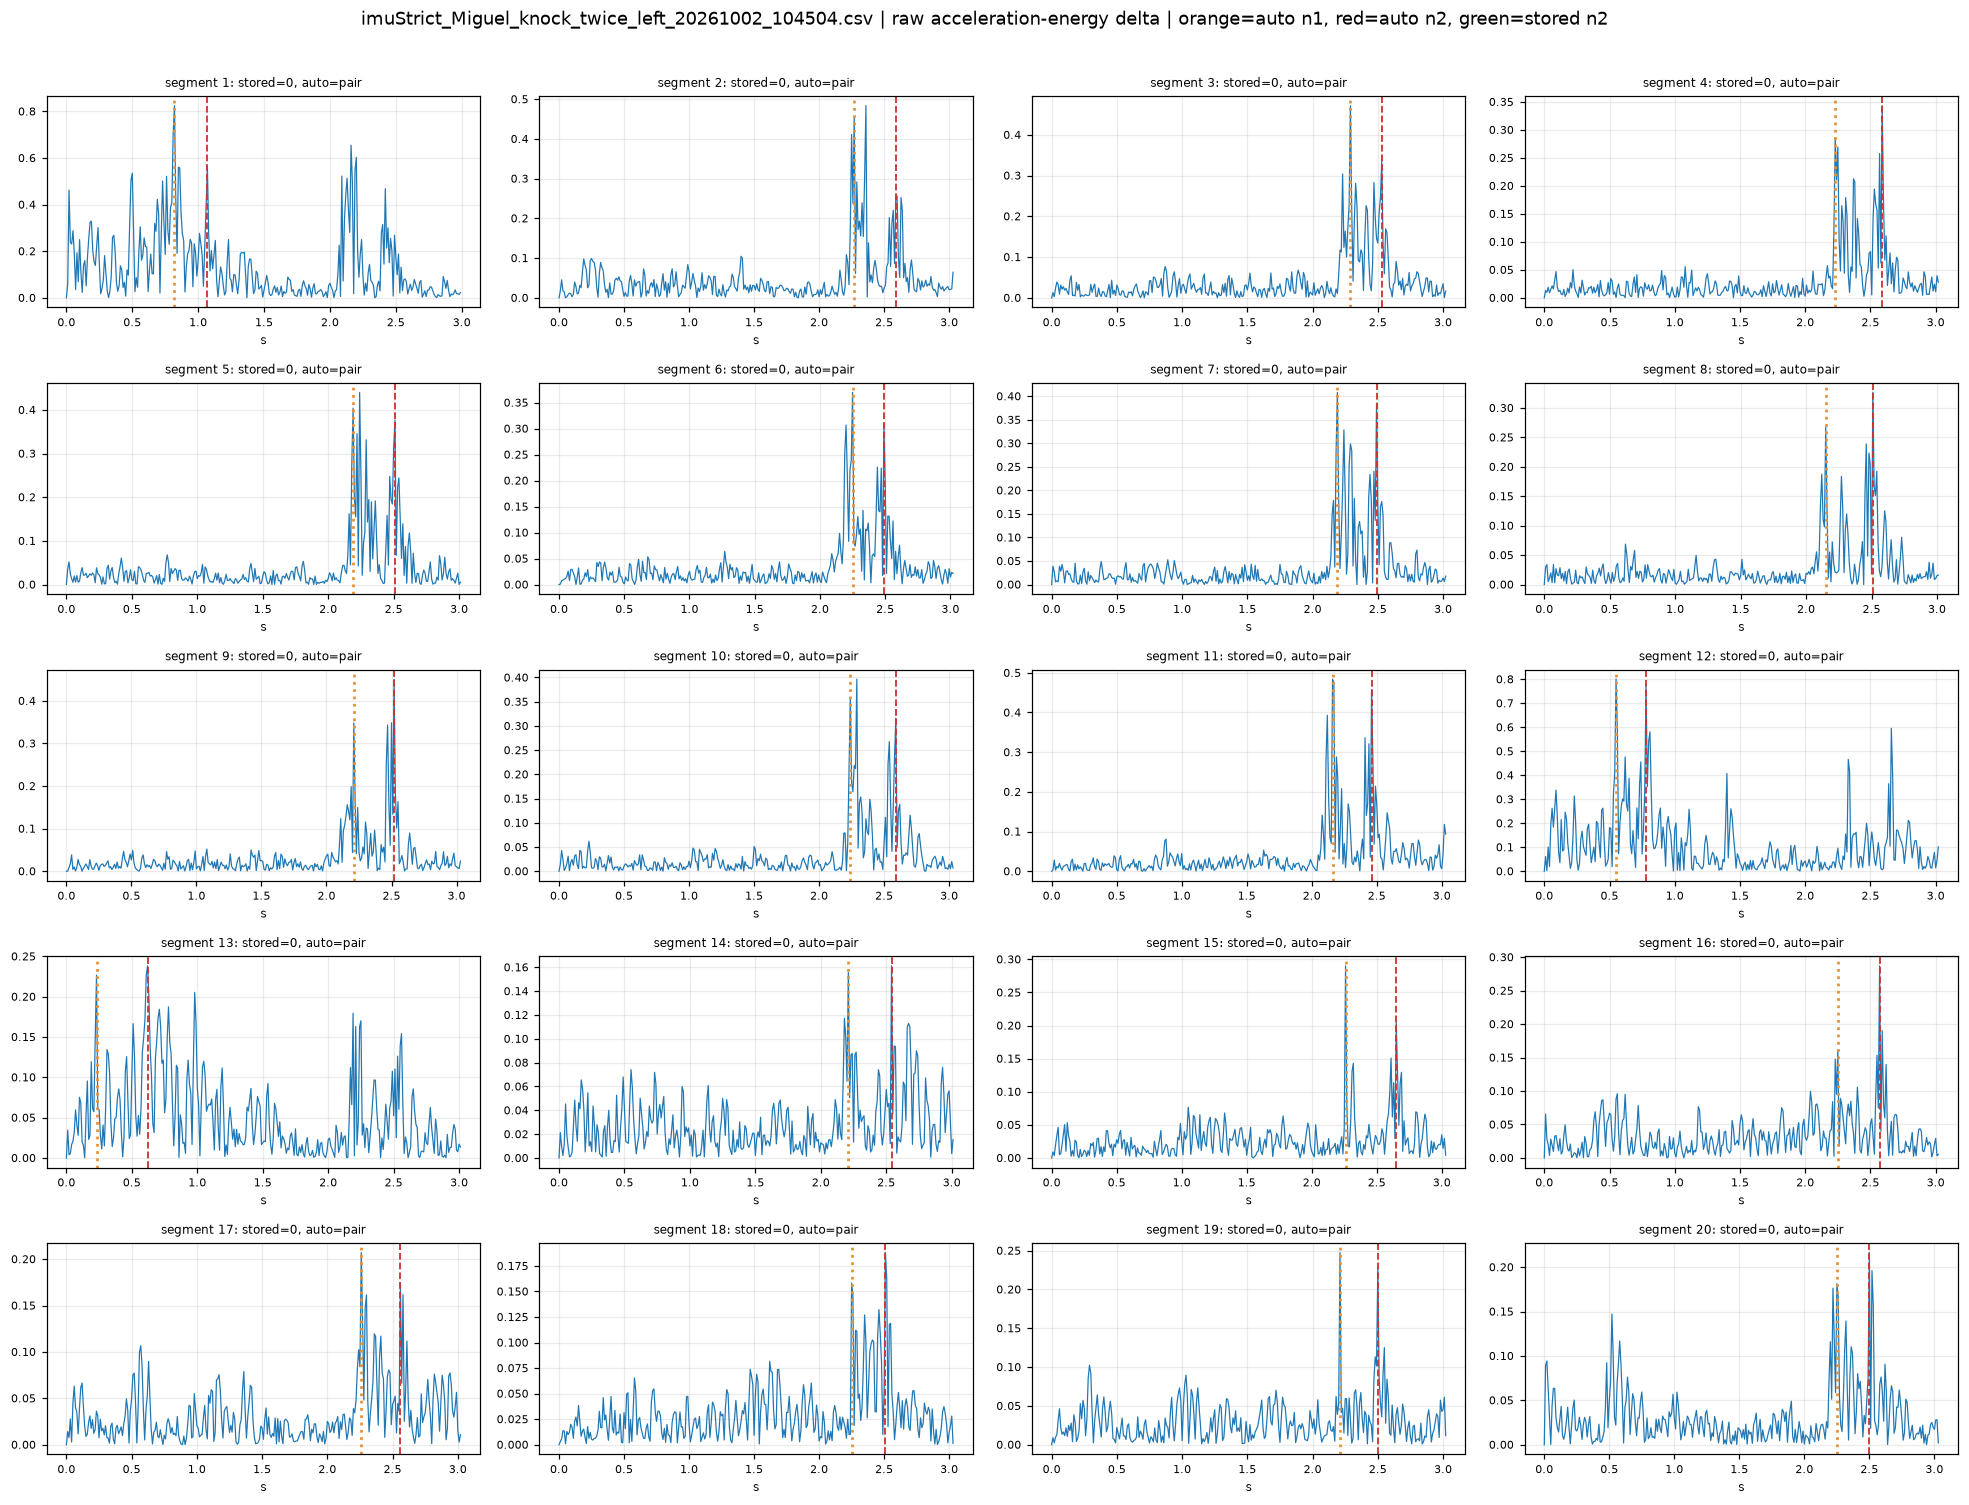

In [16]:
def plot_recording_contact_sheet(path: str | Path, columns: int = 4) -> None:
    recording = load_recording_for_review(path)
    n_segments = len(recording['bounds'])
    rows = int(np.ceil(n_segments / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(18, 2.7 * rows), sharex=False, sharey=False)
    axes = np.asarray(axes).reshape(-1)
    for segment_index, axis in enumerate(axes, start=1):
        if segment_index > n_segments:
            axis.set_visible(False)
            continue
        payload = segment_payload(recording, segment_index)
        energy = acc_energy_delta(payload['imu'][:, :3])
        t = np.arange(len(energy)) / payload['sample_rate']
        axis.plot(t, energy, color='#1f77b4', linewidth=0.8)
        add_markers(axis, payload, show_legend=False)
        stored = len(payload['events'])
        auto = 'pair' if payload['auto_n1'] is not None else 'no pair'
        axis.set_title(f'segment {segment_index}: stored={stored}, auto={auto}', fontsize=8)
        axis.set_xlabel('s', fontsize=8)
        axis.tick_params(labelsize=7)
    fig.suptitle(
        f"{recording['path'].name} | raw acceleration-energy delta | orange=auto n1, red=auto n2, green=stored n2",
        fontsize=12,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_recording_contact_sheet(CSV_PATH)


In [14]:
# Set this to True only when you want to render every recording.
# It produces 46 large figures, one contact sheet per CSV.
RENDER_ALL_CONTACT_SHEETS = False

if RENDER_ALL_CONTACT_SHEETS:
    for csv_path in CSV_PATHS:
        plot_recording_contact_sheet(csv_path)
else:
    print('Set RENDER_ALL_CONTACT_SHEETS = True to review all 920 segments as contact sheets.')


Set RENDER_ALL_CONTACT_SHEETS = True to review all 920 segments as contact sheets.


### Renderizar cada vista detallada

La funcion anterior produce un resumen compacto de los 20 segmentos de cada archivo. La opcion siguiente ejecuta la figura detallada de cinco filas para **cada uno de los 920 segmentos**, incluidos acelerometro, giroscopio, n1 y n2. Es deliberadamente opcional: mostrar 920 figuras en una sola sesion de Jupyter es lento y consume bastante memoria. Usala por subconjuntos cuando hagas una revision exhaustiva.


In [6]:
# Defaults to all 46 recordings. Replace with [CSV_PATH] or another subset when needed.
DETAILED_REVIEW_PATHS = CSV_PATHS
RENDER_ALL_DETAILED_SEGMENTS = False

if RENDER_ALL_DETAILED_SEGMENTS:
    for csv_path in DETAILED_REVIEW_PATHS:
        recording = load_recording_for_review(csv_path)
        for segment_index in range(1, len(recording['bounds']) + 1):
            plot_segment_review(csv_path, segment_index)
else:
    print('Set RENDER_ALL_DETAILED_SEGMENTS = True after choosing DETAILED_REVIEW_PATHS.')


Set RENDER_ALL_DETAILED_SEGMENTS = True after choosing DETAILED_REVIEW_PATHS.


## Controles negativos dificiles

Los segmentos de acciones negativas tienen sidecars vacios por protocolo. Aun asi, podemos ejecutar el detector de picos sobre ellos para encontrar movimientos como `shake_phone`, `pick_place` o `adjust_grip` que producen una pareja de picos con separacion valida. Estos no son errores de etiqueta: son casos negativos utiles para revisar y para evaluar despues el detector neuronal.


,path,action,segment_index,n1_frame,n2_frame,delta_t_sec,n1_robust_z,n2_robust_z,weakest_peak
609,data/valid_data/imu_Miguel_shake_phone_2026092...,shake_phone,2,408,422,0.14,425.768892,261.753038,261.753038
777,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,19,5507,5529,0.22,249.158604,295.499338,249.158604
772,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,14,3997,4010,0.13,200.211441,204.764997,200.211441
778,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,20,5811,5824,0.13,193.818193,218.716364,193.818193
766,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,8,2170,2182,0.12,186.713466,189.972331,186.713466
758,data/valid_data/imu_ZR_shake_phone_20260904_10...,shake_phone,20,5864,5897,0.33,190.282171,184.341749,184.341749
335,data/train_data/imu_Miguel_shake_phone_2026092...,shake_phone,10,2832,2846,0.14,257.475787,179.870982,179.870982
770,data/valid_data/imu_ZR_shake_phone_20260908_17...,shake_phone,12,3394,3411,0.17,185.432886,157.719103,157.719103
756,data/valid_data/imu_ZR_shake_phone_20260904_10...,shake_phone,18,5226,5244,0.18,152.659244,270.298272,152.659244
185,data/train_data/imu_Miguel_pick_place_20260924...,pick_place,17,5017,5032,0.15,146.727317,193.431376,146.727317


Showing the strongest candidate next. Change the row selection to inspect another one.


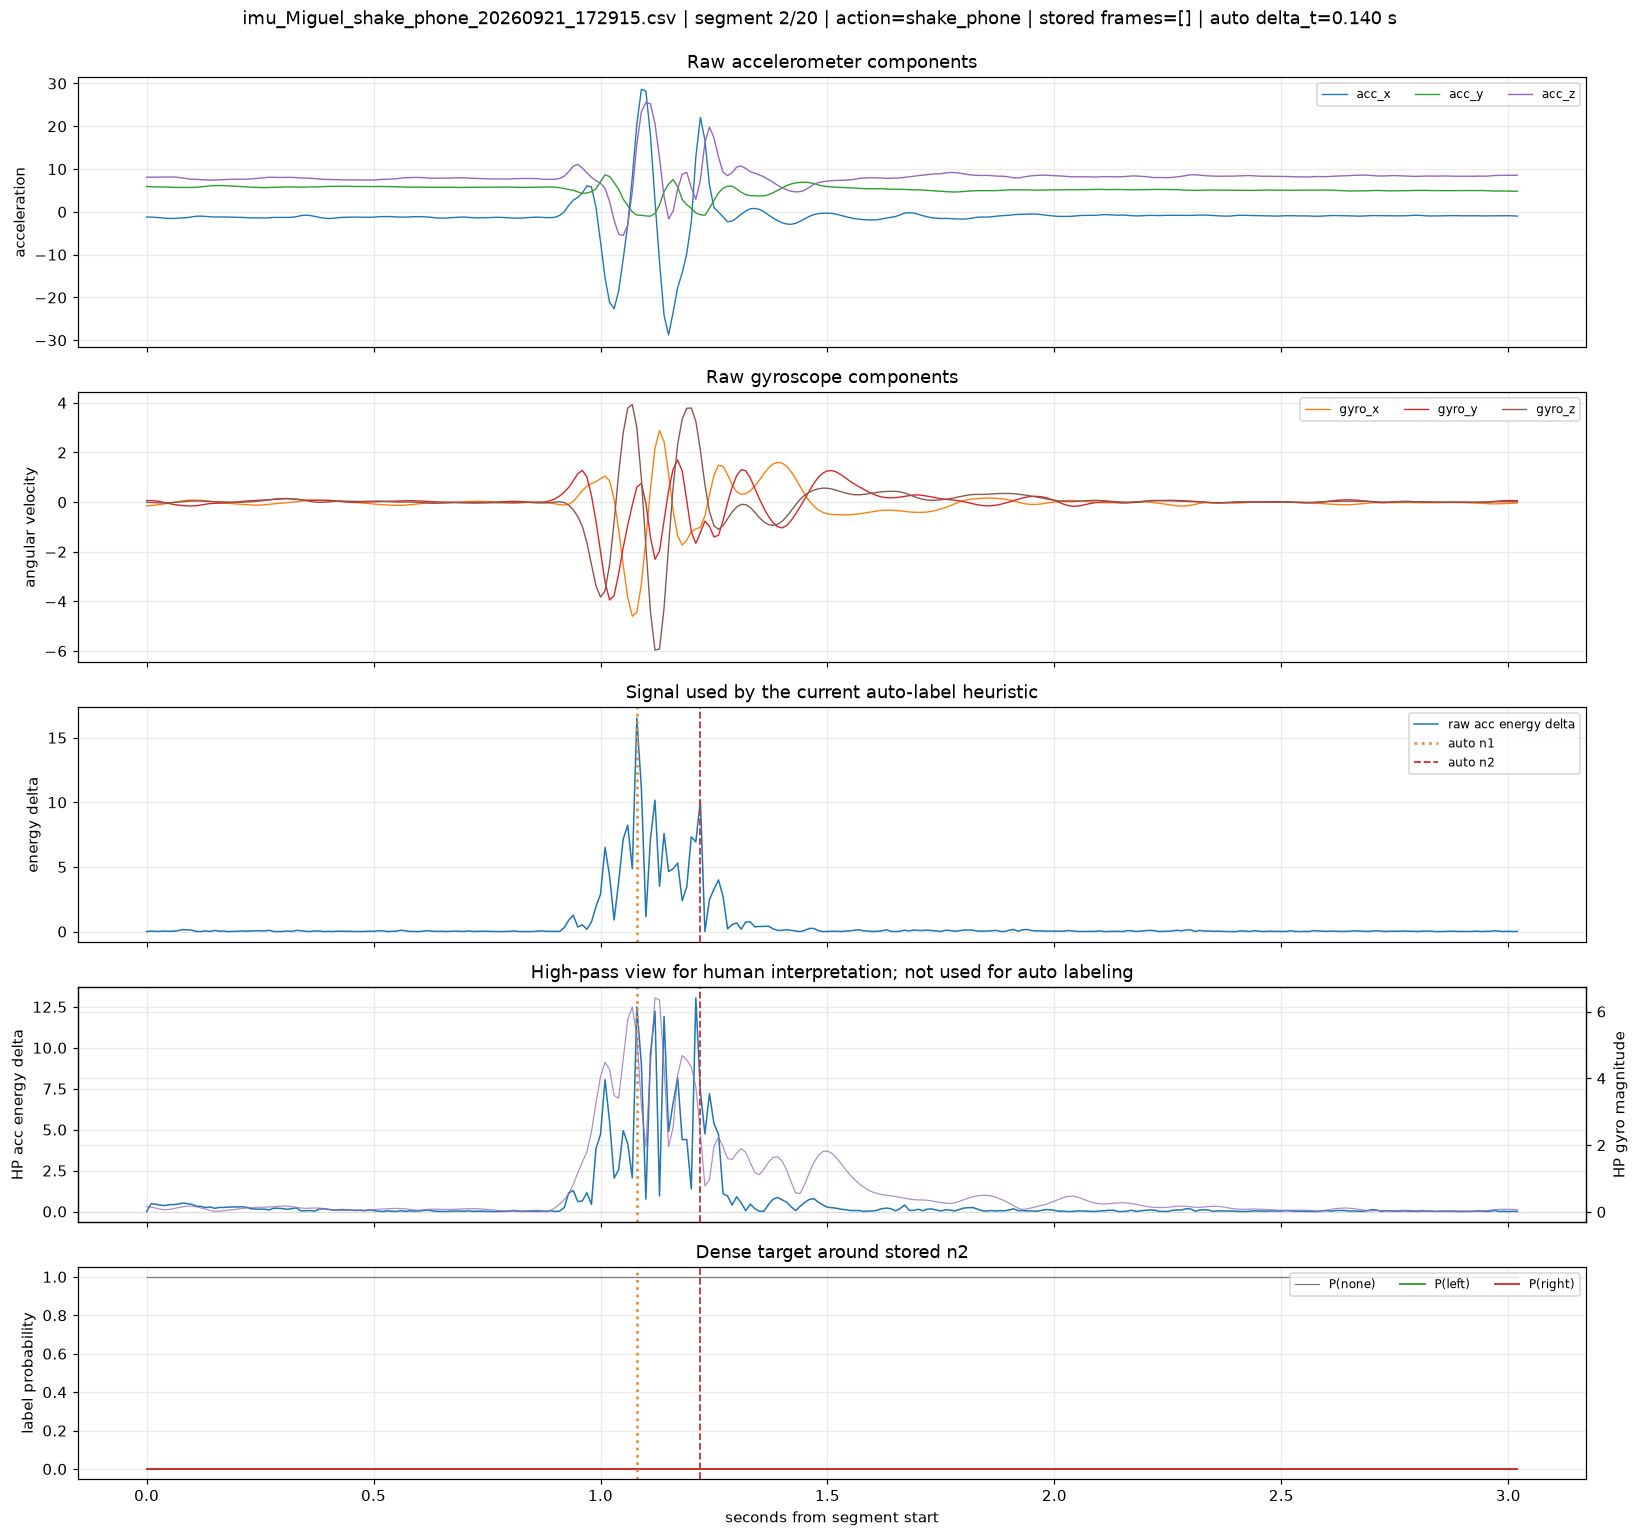

In [7]:
def robust_z(value: float, values: np.ndarray) -> float:
    median = float(np.median(values))
    mad = float(np.median(np.abs(values - median)))
    scale = 1.4826 * mad
    return 0.0 if scale < 1e-8 else (value - median) / scale


def hard_negative_candidates() -> pd.DataFrame:
    rows = []
    for csv_path in CSV_PATHS:
        recording = load_recording_for_review(csv_path)
        action = recording['metadata'].get('action_label', '')
        if action in POSITIVE_ACTION_TO_CLASS:
            continue
        energy = acc_energy_delta(recording['imu'][:, :3])
        for segment_index, (start, end) in enumerate(recording['bounds'], start=1):
            pair = detect_second_tap_frame(
                recording['imu'][start:end, :3],
                recording['imu'][start:end, 3:],
                sample_rate=recording['sample_rate'],
            )
            if pair is None:
                continue
            n1, n2 = start + pair[0], start + pair[1]
            local_energy = energy[start:end]
            rows.append({
                'path': str(csv_path.relative_to(REPO_ROOT)),
                'action': action,
                'segment_index': segment_index,
                'n1_frame': n1,
                'n2_frame': n2,
                'delta_t_sec': (n2 - n1) / recording['sample_rate'],
                'n1_robust_z': robust_z(float(energy[n1]), local_energy),
                'n2_robust_z': robust_z(float(energy[n2]), local_energy),
            })
    candidates = pd.DataFrame(rows)
    if candidates.empty:
        return candidates
    return candidates.assign(weakest_peak=candidates[['n1_robust_z', 'n2_robust_z']].min(axis=1)).sort_values('weakest_peak', ascending=False)


negative_candidates = hard_negative_candidates()
display(negative_candidates.head(30))

if not negative_candidates.empty:
    top = negative_candidates.iloc[0]
    print('Showing the strongest candidate next. Change the row selection to inspect another one.')
    plot_segment_review(top['path'], int(top['segment_index']))


## Registro manual de veredictos

Ejecuta primero la celda siguiente para obtener las 520 filas positivas. Despues anade decisiones a `review_decisions` y vuelve a ejecutar la celda. El registro vive en el notebook hasta que lo guardes, por lo que no modifica el dataset original.

Ejemplo de una decision:

```python
{'path': 'data/train_data/imu_CC_knock_twice_left_20260901_153310.csv',
 'segment_index': 1, 'verdict': 'correct', 'notes': 'Both impacts are visually distinct.'}
```


In [8]:
positive_review_rows = []
for csv_path in CSV_PATHS:
    recording = load_recording_for_review(csv_path)
    action = recording['metadata'].get('action_label', '')
    if action not in POSITIVE_ACTION_TO_CLASS:
        continue
    for segment_index in range(1, len(recording['bounds']) + 1):
        payload = segment_payload(recording, segment_index)
        positive_review_rows.append({
            'path': str(csv_path.relative_to(REPO_ROOT)),
            'action': action,
            'segment_index': segment_index,
            'stored_n2': payload['events'][0][0] if len(payload['events']) == 1 else np.nan,
            'auto_n1': payload['auto_n1'],
            'auto_n2': payload['auto_n2'],
        })

review_decisions = [
    # Paste one dictionary per reviewed segment here.
    # {'path': 'data/train_data/imu_CC_knock_twice_left_20260901_153310.csv', 'segment_index': 1, 'verdict': 'correct', 'notes': 'Both impacts are distinct.'},
]

allowed_verdicts = {'correct', 'uncertain', 'incorrect'}
reviews = pd.DataFrame(review_decisions, columns=['path', 'segment_index', 'verdict', 'notes'])
if not reviews.empty:
    invalid = reviews.loc[~reviews['verdict'].isin(allowed_verdicts)]
    if not invalid.empty:
        raise ValueError(f"Unsupported verdicts: {invalid['verdict'].tolist()}")
    duplicated = reviews.duplicated(['path', 'segment_index'], keep=False)
    if duplicated.any():
        raise ValueError('Each segment may have only one manual verdict.')

review_table = pd.DataFrame(positive_review_rows).merge(
    reviews,
    how='left',
    on=['path', 'segment_index'],
).fillna({'verdict': 'pending', 'notes': ''})

print('Manual review progress:')
display(review_table['verdict'].value_counts(dropna=False).rename_axis('verdict').to_frame('segments'))
display(review_table[review_table['verdict'] != 'pending'].sort_values(['verdict', 'path', 'segment_index']))
print('Rows still pending:', int((review_table['verdict'] == 'pending').sum()))


Manual review progress:


,segments
verdict,
pending,1420


,path,action,segment_index,stored_n2,auto_n1,auto_n2,verdict,notes


Rows still pending: 1420


## Revision checklist

When looking at a positive segment, answer these questions before marking it `correct`:

1. Are there two distinct physical impacts, rather than one impact plus ringing?
2. Is the green stored `n2` on the second impact rather than on a later vibration?
3. Does the orange `n1` plausibly identify the first impact?
4. Is the interval physically plausible and within the intended double-tap behavior?
5. Does the waveform look similar to the other 19 repetitions for this action and user?
6. For a hard negative, would this motion be easy for a deployed detector to confuse with a double tap?

Do not change a sidecar until the review protocol and the intended source of truth have been agreed. Otherwise the same ambiguity can be encoded differently in sparse and dense labels.
